<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day4_state_discovery/Day4_0_PCA_eigen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Principal Component Analysis (PCA) for Behavioral Data

## Learning Objectives

By the end of this tutorial, you will:
- Understand what eigenvectors and eigenvalues represent geometrically
- Interpret the meaning of large vs. small eigenvalues
- Apply PCA to high-dimensional behavioral data
- Visualize and interpret principal components

---

## Setup

In [1]:
# Install required packages
!pip install plotly scikit-learn -q

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("✓ Setup complete!")

✓ Setup complete!


---

# Part 1: Building Intuition - What are Eigenvectors and Eigenvalues?

## 1.1 The Fundamental Equation

An **eigenvector** of a matrix $A$ is a special vector $\mathbf{v}$ that, when multiplied by $A$, only gets scaled (stretched or compressed) but doesn't change direction:

$$A\mathbf{v} = \lambda\mathbf{v}$$

where:
- $\mathbf{v}$ is the **eigenvector** (direction)
- $\lambda$ is the **eigenvalue** (scale factor)

### What does this mean intuitively?

Think of a matrix as a **transformation** that stretches, rotates, or skews space:
- **Eigenvectors** are the special directions that don't get rotated
- **Eigenvalues** tell you how much stretching happens in each direction

Let's visualize this!

In [2]:
# Create a simple 2D transformation matrix
# This matrix stretches space differently in different directions
A = np.array([[3, 1],
              [1, 2]])

# Calculate eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:")
print(A)
print("\nEigenvalues (λ):", eigenvalues)
print("\nEigenvectors (v):")
print(eigenvectors)

# Let's verify: A*v should equal λ*v
for i in range(2):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    
    Av = A @ v  # Matrix multiplication
    lam_v = lam * v
    
    print(f"\nEigenvector {i+1}:")
    print(f"  A*v = {Av}")
    print(f"  λ*v = {lam_v}")
    print(f"  Equal? {np.allclose(Av, lam_v)}")

Matrix A:
[[3 1]
 [1 2]]

Eigenvalues (λ): [3.61803399 1.38196601]

Eigenvectors (v):
[[ 0.85065081 -0.52573111]
 [ 0.52573111  0.85065081]]

Eigenvector 1:
  A*v = [3.07768354 1.90211303]
  λ*v = [3.07768354 1.90211303]
  Equal? True

Eigenvector 2:
  A*v = [-0.72654253  1.1755705 ]
  λ*v = [-0.72654253  1.1755705 ]
  Equal? True


/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_93101/457074054.py:50: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_93101/457074054.py:50: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/miao/miniconda3/envs/eco/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/miao/miniconda3/envs/eco/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


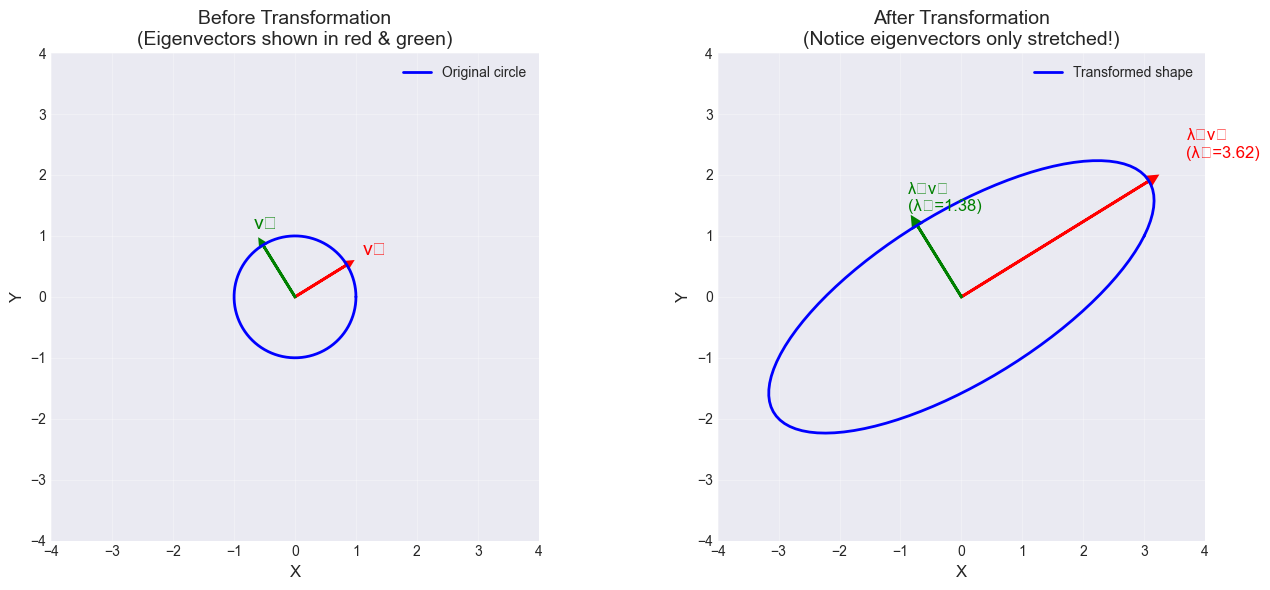


🔍 Key Observation:
The circle became an ellipse, but the eigenvectors (red & green arrows)
stayed in the same DIRECTION - they only got SCALED by their eigenvalues!


In [ ]:
# Visualize how the matrix transforms space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Create a circle of points
theta = np.linspace(0, 2*np.pi, 100)
circle_points = np.array([np.cos(theta), np.sin(theta)])

# Transform the circle
transformed_points = A @ circle_points

# Plot original space
ax1.plot(circle_points[0], circle_points[1], 'b-', linewidth=2, label='Original circle')
ax1.arrow(0, 0, eigenvectors[0, 0], eigenvectors[1, 0], 
          head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=2)
ax1.arrow(0, 0, eigenvectors[0, 1], eigenvectors[1, 1], 
          head_width=0.1, head_length=0.1, fc='green', ec='green', linewidth=2)
ax1.text(eigenvectors[0, 0]*1.3, eigenvectors[1, 0]*1.3, 'v₁', fontsize=14, color='red')
ax1.text(eigenvectors[0, 1]*1.3, eigenvectors[1, 1]*1.3, 'v₂', fontsize=14, color='green')
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_title('Before Transformation\n(Eigenvectors shown in red & green)', fontsize=14)
ax1.legend()

# Plot transformed space
ax2.plot(transformed_points[0], transformed_points[1], 'b-', linewidth=2, label='Transformed shape')
# Transformed eigenvectors
v1_transformed = A @ eigenvectors[:, 0]
v2_transformed = A @ eigenvectors[:, 1]
ax2.arrow(0, 0, v1_transformed[0], v1_transformed[1], 
          head_width=0.15, head_length=0.15, fc='red', ec='red', linewidth=2)
ax2.arrow(0, 0, v2_transformed[0], v2_transformed[1], 
          head_width=0.15, head_length=0.15, fc='green', ec='green', linewidth=2)
ax2.text(v1_transformed[0]*1.2, v1_transformed[1]*1.2, f'λ₁v₁\n(λ₁={eigenvalues[0]:.2f})', 
         fontsize=12, color='red')
ax2.text(v2_transformed[0]*1.2, v2_transformed[1]*1.2, f'λ₂v₂\n(λ₂={eigenvalues[1]:.2f})', 
         fontsize=12, color='green')
ax2.set_xlim(-4, 4)
ax2.set_ylim(-4, 4)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_title('After Transformation\n(Notice eigenvectors only stretched!)', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n🔍 Key Observation:")
print("The circle became an ellipse, but the eigenvectors (red & green arrows)")
print("stayed in the same DIRECTION - they only got SCALED by their eigenvalues!")

## 1.2 Understanding Eigenvalues

### What does the magnitude of an eigenvalue tell us?

- **Large eigenvalue (|λ| >> 1)**: The matrix **stretches** space a lot in this direction
  - This direction captures a lot of variance/variability
  - Important for describing the data
  
- **Small eigenvalue (|λ| ≈ 0)**: The matrix **compresses** space in this direction
  - Little variance in this direction
  - Less important for describing the data
  
- **Eigenvalue = 1**: No stretching or compression (preserved)

### What about the sign?

- **Positive eigenvalue (λ > 0)**: Direction is preserved
- **Negative eigenvalue (λ < 0)**: Direction is flipped (reflected)
  
**Important**: For PCA, we work with **covariance matrices**, which are always:
- Symmetric
- Positive semi-definite
- Therefore, **all eigenvalues are ≥ 0** (no flipping!)

Let's explore this with examples:

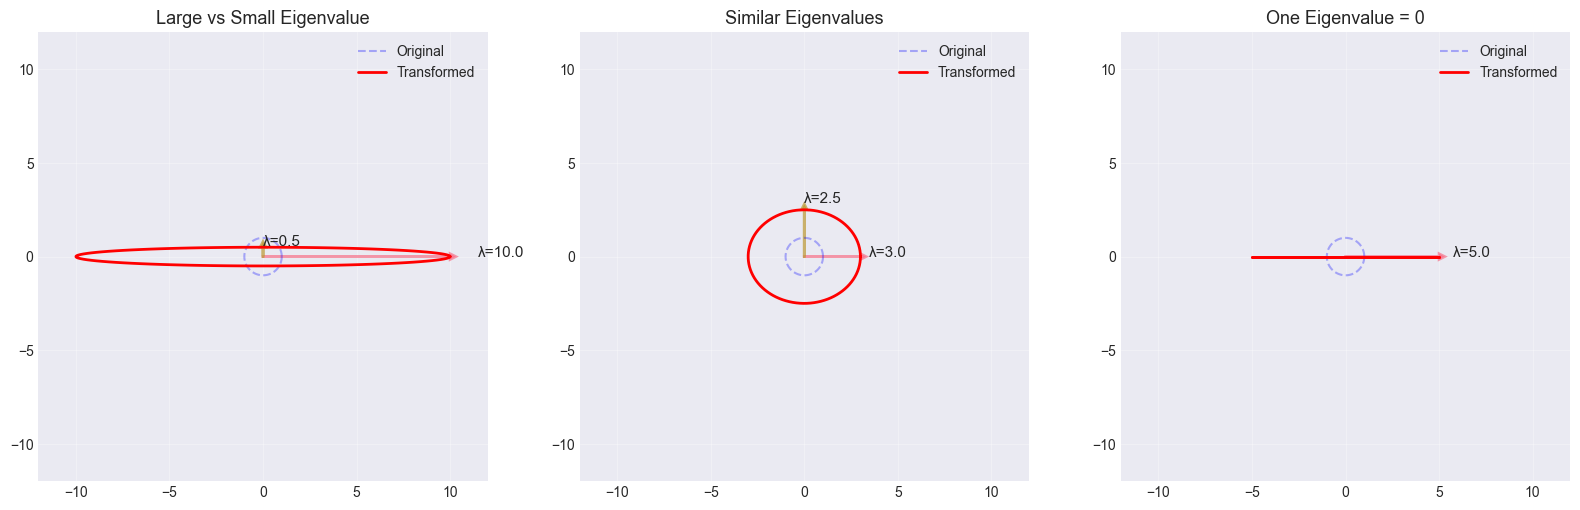


📊 Interpretation:
Left: λ₁=10 >> λ₂=0.5 → Data varies much more in one direction (elongated ellipse)
Middle: λ₁=3 ≈ λ₂=2.5 → Data varies similarly in both directions (circular ellipse)
Right: λ₁=5, λ₂=0 → Data has NO variation in one direction (collapsed to a line!)


In [4]:
# Example 1: Very different eigenvalues (one dimension dominates)
A1 = np.array([[10, 0],
               [0, 0.5]])

# Example 2: Similar eigenvalues (balanced)
A2 = np.array([[3, 0],
               [0, 2.5]])

# Example 3: One eigenvalue is zero (data is 1D!)
A3 = np.array([[5, 0],
               [0, 0]])

matrices = [A1, A2, A3]
titles = ['Large vs Small Eigenvalue', 'Similar Eigenvalues', 'One Eigenvalue = 0']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, A, title in zip(axes, matrices, titles):
    # Create circle and transform
    theta = np.linspace(0, 2*np.pi, 100)
    circle = np.array([np.cos(theta), np.sin(theta)])
    transformed = A @ circle
    
    # Get eigenvalues
    evals, evecs = np.linalg.eig(A)
    
    # Plot
    ax.plot(circle[0], circle[1], 'b--', alpha=0.3, label='Original')
    ax.plot(transformed[0], transformed[1], 'r-', linewidth=2, label='Transformed')
    
    # Plot eigenvectors
    for i in range(2):
        if evals[i] > 0.01:  # Only plot if eigenvalue is significant
            v = A @ evecs[:, i]
            ax.arrow(0, 0, v[0], v[1], head_width=0.3, head_length=0.3, 
                    fc=f'C{i}', ec=f'C{i}', linewidth=2, alpha=0.7)
            ax.text(v[0]*1.15, v[1]*1.15, f'λ={evals[i]:.1f}', fontsize=11)
    
    ax.set_xlim(-12, 12)
    ax.set_ylim(-12, 12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=13)
    ax.legend()

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("Left: λ₁=10 >> λ₂=0.5 → Data varies much more in one direction (elongated ellipse)")
print("Middle: λ₁=3 ≈ λ₂=2.5 → Data varies similarly in both directions (circular ellipse)")
print("Right: λ₁=5, λ₂=0 → Data has NO variation in one direction (collapsed to a line!)")

---

# Part 2: Connecting to PCA

## 2.1 What is PCA?

**Principal Component Analysis (PCA)** finds the directions of maximum variance in your data.

### The PCA Algorithm:

1. **Center the data**: Subtract the mean from each feature
2. **Compute covariance matrix**: $C = \frac{1}{n-1}X^TX$ (measures how features vary together)
3. **Find eigenvectors and eigenvalues** of the covariance matrix
4. **Sort by eigenvalue**: Largest eigenvalue = most variance = 1st principal component
5. **Project data**: Transform data into new coordinate system defined by eigenvectors

### Why the covariance matrix?

The covariance matrix tells us:
- **Diagonal elements**: Variance of each feature
- **Off-diagonal elements**: Covariance between features (how they vary together)

$$C = \begin{bmatrix} 
\text{var}(x_1) & \text{cov}(x_1, x_2) \\
\text{cov}(x_2, x_1) & \text{var}(x_2)
\end{bmatrix}$$

Let's see this with real data!

In [5]:
# Generate correlated 2D data (like animal movement: speed and acceleration might be correlated)
np.random.seed(42)
n_samples = 300

# Generate data with strong correlation
mean = [0, 0]
cov = [[3, 2.5],    # Feature 1 variance=3, covariance=2.5
       [2.5, 2]]    # Feature 2 variance=2

data = np.random.multivariate_normal(mean, cov, n_samples)

# Compute covariance matrix
data_centered = data - data.mean(axis=0)
cov_matrix = np.cov(data_centered.T)

print("Covariance Matrix:")
print(cov_matrix)
print("\nInterpretation:")
print(f"  Variance of Feature 1: {cov_matrix[0, 0]:.2f}")
print(f"  Variance of Feature 2: {cov_matrix[1, 1]:.2f}")
print(f"  Covariance: {cov_matrix[0, 1]:.2f} (positive = features increase together)")

# Get eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by eigenvalue (largest first)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nEigenvalues (sorted):", eigenvalues)
print("Eigenvectors (principal components):")
print(eigenvectors)
print(f"\nVariance explained by PC1: {eigenvalues[0] / eigenvalues.sum() * 100:.1f}%")
print(f"Variance explained by PC2: {eigenvalues[1] / eigenvalues.sum() * 100:.1f}%")

Covariance Matrix:
[[2.90836806 2.35279066]
 [2.35279066 1.98036112]]

Interpretation:
  Variance of Feature 1: 2.91
  Variance of Feature 2: 1.98
  Covariance: 2.35 (positive = features increase together)

Eigenvalues (sorted): [4.84247282 0.04625636]
Eigenvectors (principal components):
[[ 0.77249184 -0.63502469]
 [ 0.63502469  0.77249184]]

Variance explained by PC1: 99.1%
Variance explained by PC2: 0.9%


/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_93101/2566743527.py:10: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  data = np.random.multivariate_normal(mean, cov, n_samples)


/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_93101/4029467632.py:37: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/miao/miniconda3/envs/eco/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


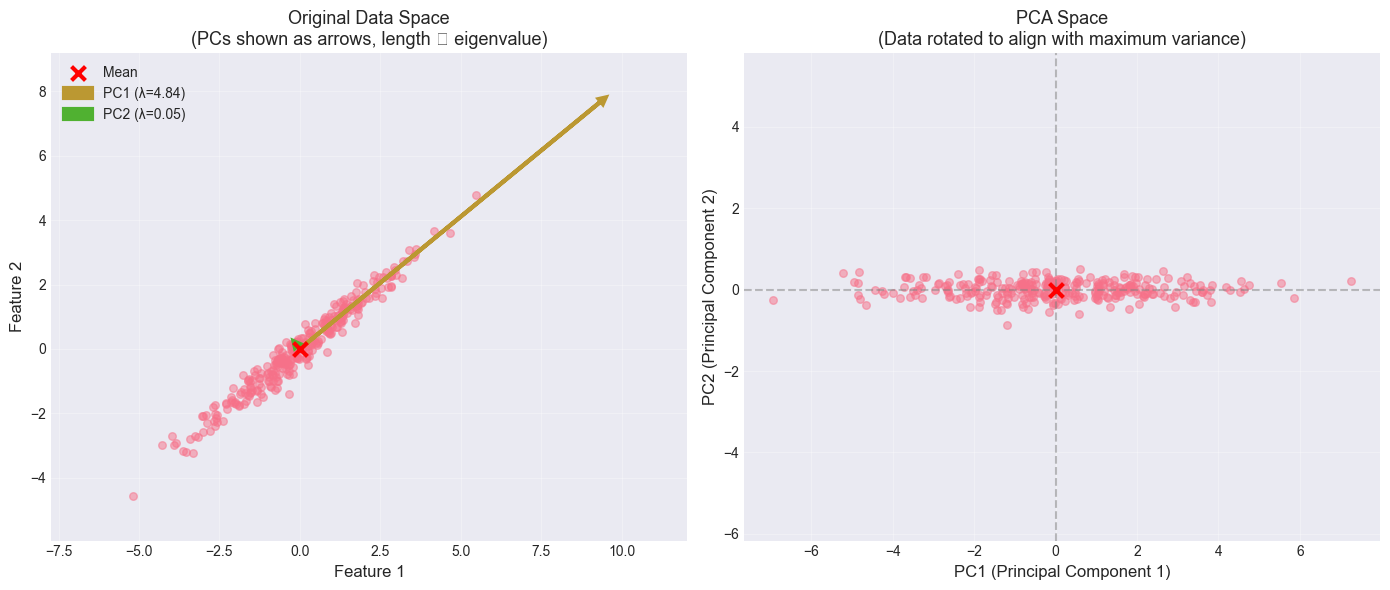


🎯 What happened?
Left: Original data is tilted (features are correlated)
Right: PCA rotated the data so PC1 captures the maximum variance direction
       Now the axes are uncorrelated (no tilt)!


In [6]:
# Visualize the data and principal components
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Original data with principal components
ax1.scatter(data[:, 0], data[:, 1], alpha=0.5, s=30)
ax1.scatter(0, 0, c='red', s=100, marker='x', linewidths=3, label='Mean', zorder=5)

# Plot principal components (scaled by eigenvalues for visualization)
scale = 2.5
for i in range(2):
    vec = eigenvectors[:, i] * eigenvalues[i] * scale
    ax1.arrow(0, 0, vec[0], vec[1], 
             head_width=0.2, head_length=0.2, fc=f'C{i+1}', ec=f'C{i+1}', 
             linewidth=3, label=f'PC{i+1} (λ={eigenvalues[i]:.2f})')

ax1.set_xlabel('Feature 1', fontsize=12)
ax1.set_ylabel('Feature 2', fontsize=12)
ax1.set_title('Original Data Space\n(PCs shown as arrows, length ∝ eigenvalue)', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Right plot: Data projected onto principal components
# Project data: multiply by eigenvectors
data_pca = data_centered @ eigenvectors

ax2.scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5, s=30)
ax2.scatter(0, 0, c='red', s=100, marker='x', linewidths=3, label='Mean', zorder=5)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('PC1 (Principal Component 1)', fontsize=12)
ax2.set_ylabel('PC2 (Principal Component 2)', fontsize=12)
ax2.set_title('PCA Space\n(Data rotated to align with maximum variance)', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

plt.tight_layout()
plt.show()

print("\n🎯 What happened?")
print("Left: Original data is tilted (features are correlated)")
print("Right: PCA rotated the data so PC1 captures the maximum variance direction")
print("       Now the axes are uncorrelated (no tilt)!")

## 2.2 Dimensionality Reduction

The power of PCA comes from **keeping only the top principal components**.

If a component has a very small eigenvalue, it means that direction has little variance → we can ignore it!

### How to choose how many components to keep?

1. **Scree plot**: Look for the "elbow" where eigenvalues drop off
2. **Cumulative variance explained**: Keep enough PCs to explain >80-90% of variance
3. **Domain knowledge**: Keep PCs that make biological sense

In [7]:
# Generate higher-dimensional data (10 features, but only 2-3 are important)
np.random.seed(42)
n_samples = 200
n_features = 10

# Create data where first 3 dimensions have structure, rest is noise
X_structured = np.random.randn(n_samples, 3) @ np.diag([5, 3, 1.5])
X_noise = np.random.randn(n_samples, 7) * 0.3
X = np.hstack([X_structured, X_noise])

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X)

print(f"Original data shape: {X.shape}")
print(f"After PCA: {X_pca.shape} (same, but rotated)")
print(f"\nEigenvalues: {pca.explained_variance_}")
print(f"\nVariance explained by each PC:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")

Original data shape: (200, 10)
After PCA: (200, 10) (same, but rotated)

Eigenvalues: [19.98911798  9.0616028   2.2587187   0.11029988  0.10481915  0.09361188
  0.08021165  0.07944444  0.07646753  0.06636894]

Variance explained by each PC:
  PC1: 62.6%
  PC2: 28.4%
  PC3: 7.1%
  PC4: 0.3%
  PC5: 0.3%
  PC6: 0.3%
  PC7: 0.3%
  PC8: 0.2%
  PC9: 0.2%
  PC10: 0.2%


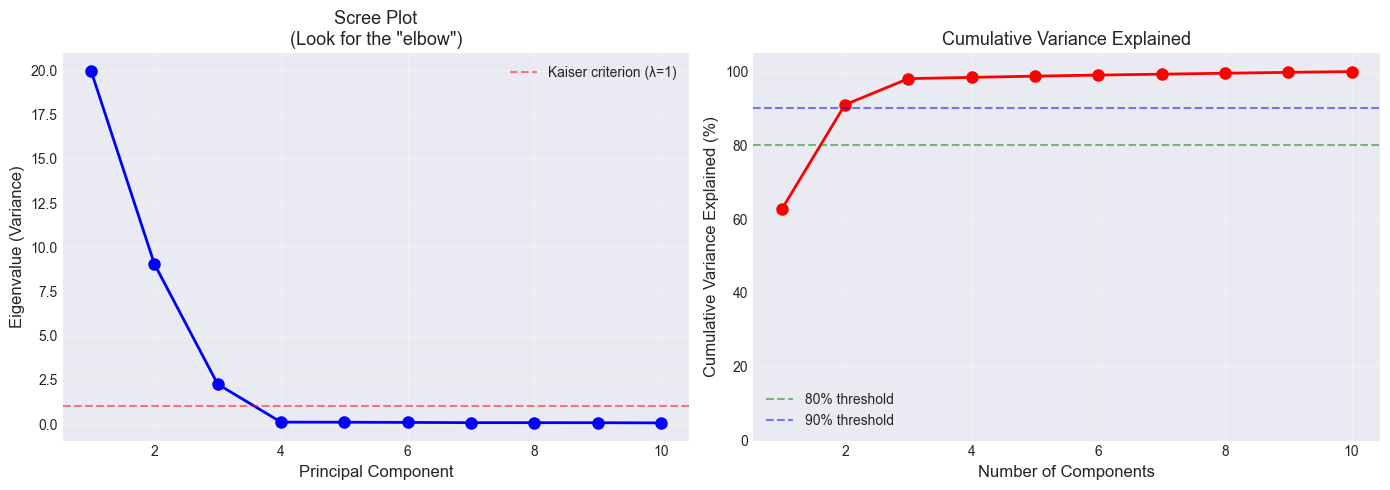


📊 Analysis:
To capture 90% of variance, we need 2 components out of 10
This is a 80% reduction in dimensionality!

First 3 eigenvalues: [19.98911798  9.0616028   2.2587187 ]
Last 3 eigenvalues: [0.07944444 0.07646753 0.06636894]
Notice how the last few are very small (noise)!


In [8]:
# Visualize eigenvalue spectrum and cumulative variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.plot(range(1, len(pca.explained_variance_) + 1), 
         pca.explained_variance_, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Eigenvalue (Variance)', fontsize=12)
ax1.set_title('Scree Plot\n(Look for the "elbow")', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.axhline(1, color='red', linestyle='--', alpha=0.5, label='Kaiser criterion (λ=1)')
ax1.legend()

# Cumulative variance explained
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
ax2.plot(range(1, len(cumvar) + 1), cumvar, 'ro-', linewidth=2, markersize=8)
ax2.axhline(80, color='green', linestyle='--', alpha=0.5, label='80% threshold')
ax2.axhline(90, color='blue', linestyle='--', alpha=0.5, label='90% threshold')
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

# Find how many PCs needed for 90% variance
n_components_90 = np.argmax(cumvar >= 90) + 1
print(f"\n📊 Analysis:")
print(f"To capture 90% of variance, we need {n_components_90} components out of {n_features}")
print(f"This is a {(1 - n_components_90/n_features)*100:.0f}% reduction in dimensionality!")
print(f"\nFirst 3 eigenvalues: {pca.explained_variance_[:3]}")
print(f"Last 3 eigenvalues: {pca.explained_variance_[-3:]}")
print("Notice how the last few are very small (noise)!")

---

# Part 3: PCA on Face Images - Eigenfaces

## 3.1 The Eigenface Dataset

Let's apply PCA to a classic computer vision problem: **face recognition**.

**The Challenge**: Each face image is 64×64 pixels = 4,096 dimensions! 
- Can we represent faces with fewer dimensions?
- What do the "principal components" of faces look like?
- These principal components are called **Eigenfaces**

**Key Insight**: While each image has 4,096 pixels, most faces share common structure (eyes, nose, mouth in similar positions). PCA will find these common patterns!

In [9]:
# Load the Labeled Faces in the Wild dataset
from sklearn.datasets import fetch_lfw_people

# Load faces with at least 70 images per person (to get enough samples)
print("Loading face dataset...")
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.5, color=False)

# Extract data
faces = lfw_people.data  # Each row is a flattened face image
n_samples, n_features = faces.shape
h, w = lfw_people.images.shape[1:]

# Get labels (person names)
target_names = lfw_people.target_names
n_people = len(target_names)

print(f"\n✓ Dataset loaded!")
print(f"Total faces: {n_samples}")
print(f"Image dimensions: {h} × {w} pixels")
print(f"Features per image: {n_features} (each pixel is a feature!)")
print(f"Number of people: {n_people}")
print(f"People: {', '.join(target_names[:5])}...")

Loading face dataset...

✓ Dataset loaded!
Total faces: 1288
Image dimensions: 62 × 47 pixels
Features per image: 2914 (each pixel is a feature!)
Number of people: 7
People: Ariel Sharon, Colin Powell, Donald Rumsfeld, George W Bush, Gerhard Schroeder...


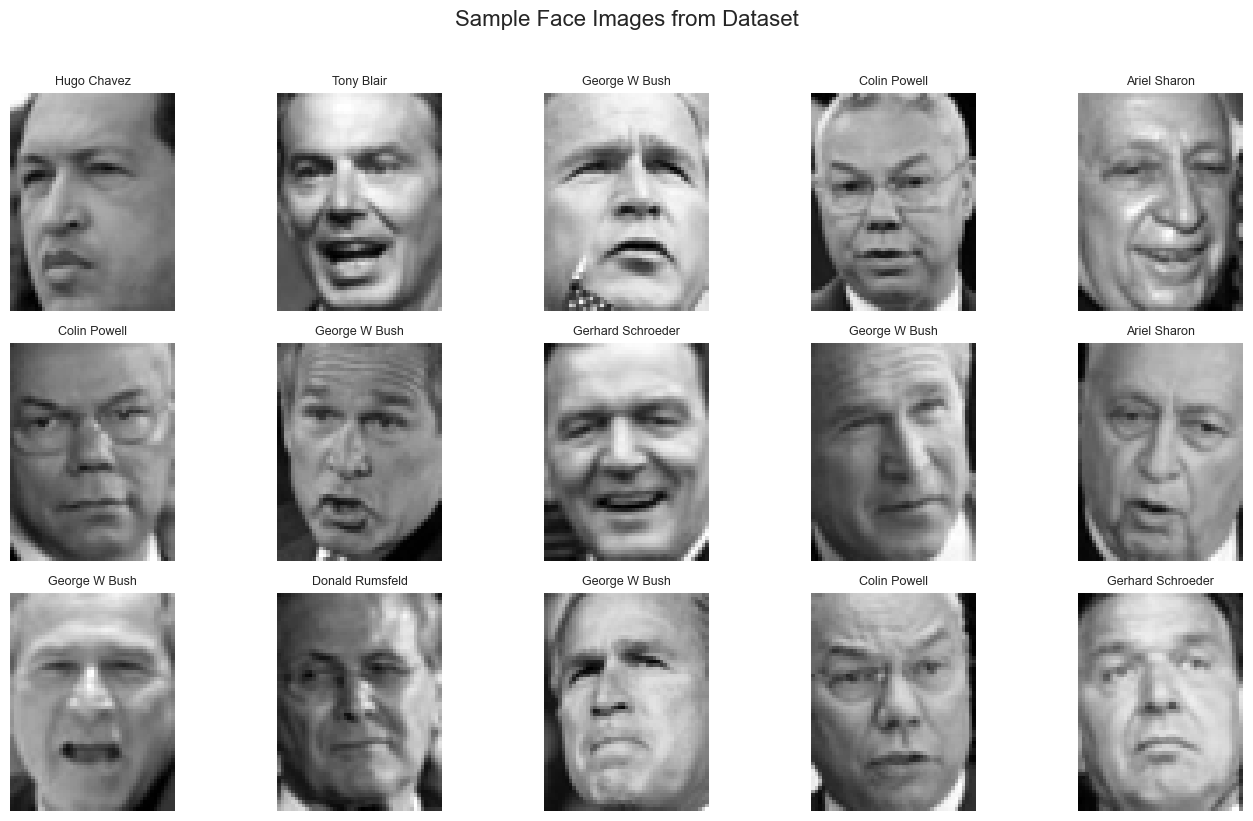


👤 Each of these images is represented as a 4,096-dimensional vector!
We'll use PCA to find a much lower-dimensional representation.


In [10]:
# Visualize some example faces
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Sample Face Images from Dataset', fontsize=16, y=1.02)

for i, ax in enumerate(axes.flat):
    if i < len(faces):
        ax.imshow(lfw_people.images[i], cmap='gray')
        ax.set_title(target_names[lfw_people.target[i]], fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\n👤 Each of these images is represented as a 4,096-dimensional vector!")
print("We'll use PCA to find a much lower-dimensional representation.")

## 3.2 Apply PCA to Find Eigenfaces

**Question**: Out of 4,096 pixel features, how many dimensions really matter for representing faces?

In [ ]:
# Standardize the data (center by subtracting mean face)
# Note: For images, we often just center without scaling to preserve relative brightness
from sklearn.preprocessing import StandardScaler

print("Computing PCA on face data...")
print("This may take a moment...\n")

# Center the data
scaler = StandardScaler(with_std=False)  # Only center, don't scale # you can also do with_std=True if you want to scale by variance
faces_centered = scaler.fit_transform(faces)

# Apply PCA - keep enough components to explain 95% of variance
n_components = 150  # We'll keep top 150 eigenfaces
pca_faces = PCA(n_components=n_components, whiten=True)
faces_pca = pca_faces.fit_transform(faces_centered)

print("✓ PCA complete!")
print(f"\nOriginal dimensions: {n_features:,}")
print(f"Reduced dimensions: {n_components}")
print(f"Dimensionality reduction: {(1 - n_components/n_features)*100:.1f}%")
print(f"\nTotal variance explained: {pca_faces.explained_variance_ratio_.sum()*100:.1f}%")
print(f"\nTop 10 eigenvalues:")
for i in range(10):
    print(f"  PC{i+1}: {pca_faces.explained_variance_[i]:.1f} ({pca_faces.explained_variance_ratio_[i]*100:.2f}%)")

Computing PCA on face data...
This may take a moment...

✓ PCA complete!

Original dimensions: 2,914
Reduced dimensions: 150
Dimensionality reduction: 94.9%

Total variance explained: 93.6%

Top 10 eigenvalues:
  PC1: 13.3 (20.30%)
  PC2: 9.0 (13.77%)
  PC3: 4.5 (6.84%)
  PC4: 3.7 (5.63%)
  PC5: 3.1 (4.80%)
  PC6: 1.9 (2.84%)
  PC7: 1.5 (2.33%)
  PC8: 1.3 (2.01%)
  PC9: 1.2 (1.91%)
  PC10: 1.2 (1.80%)


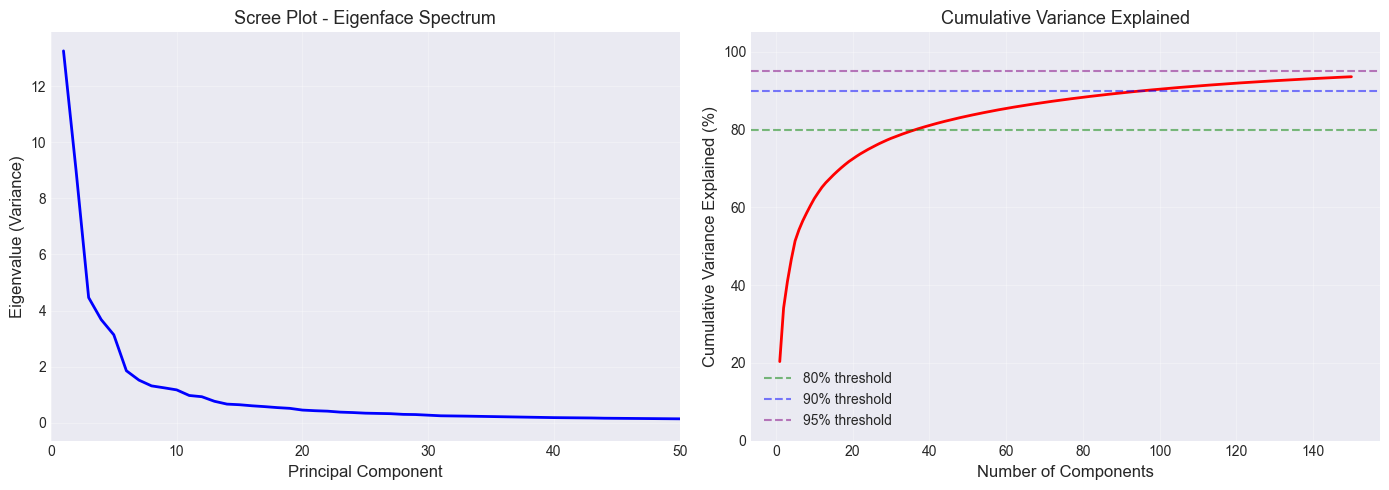

For 80% variance: 37 components (reduction: 98.7%)
For 90% variance: 96 components (reduction: 96.7%)
For 95% variance: 1 components (reduction: 100.0%)


In [12]:
# Visualize eigenvalue spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.plot(range(1, n_components + 1), pca_faces.explained_variance_, 
         'b-', linewidth=2)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Eigenvalue (Variance)', fontsize=12)
ax1.set_title('Scree Plot - Eigenface Spectrum', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 50])  # Focus on first 50

# Cumulative variance
cumvar = np.cumsum(pca_faces.explained_variance_ratio_) * 100
ax2.plot(range(1, len(cumvar) + 1), cumvar, 'r-', linewidth=2)
ax2.axhline(80, color='green', linestyle='--', alpha=0.5, label='80% threshold')
ax2.axhline(90, color='blue', linestyle='--', alpha=0.5, label='90% threshold')
ax2.axhline(95, color='purple', linestyle='--', alpha=0.5, label='95% threshold')
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

# Find how many PCs needed for different thresholds
for threshold in [80, 90, 95]:
    n_comp = np.argmax(cumvar >= threshold) + 1
    print(f"For {threshold}% variance: {n_comp} components (reduction: {(1-n_comp/n_features)*100:.1f}%)")

## 3.3 Visualizing Eigenfaces - What Do They Look Like?

The principal components are vectors in the original pixel space. When we reshape them back to image form, we get **Eigenfaces**!

**Interpretation**:
- **First eigenface** (PC1): Captures the most variance - typically overall brightness/lighting
- **Later eigenfaces**: Capture more specific facial features
- **Each face** can be written as a weighted sum of eigenfaces!

$$\text{Face} = \text{mean face} + w_1 \cdot \text{Eigenface}_1 + w_2 \cdot \text{Eigenface}_2 + ... $$

where $w_i$ are the weights (PC scores)

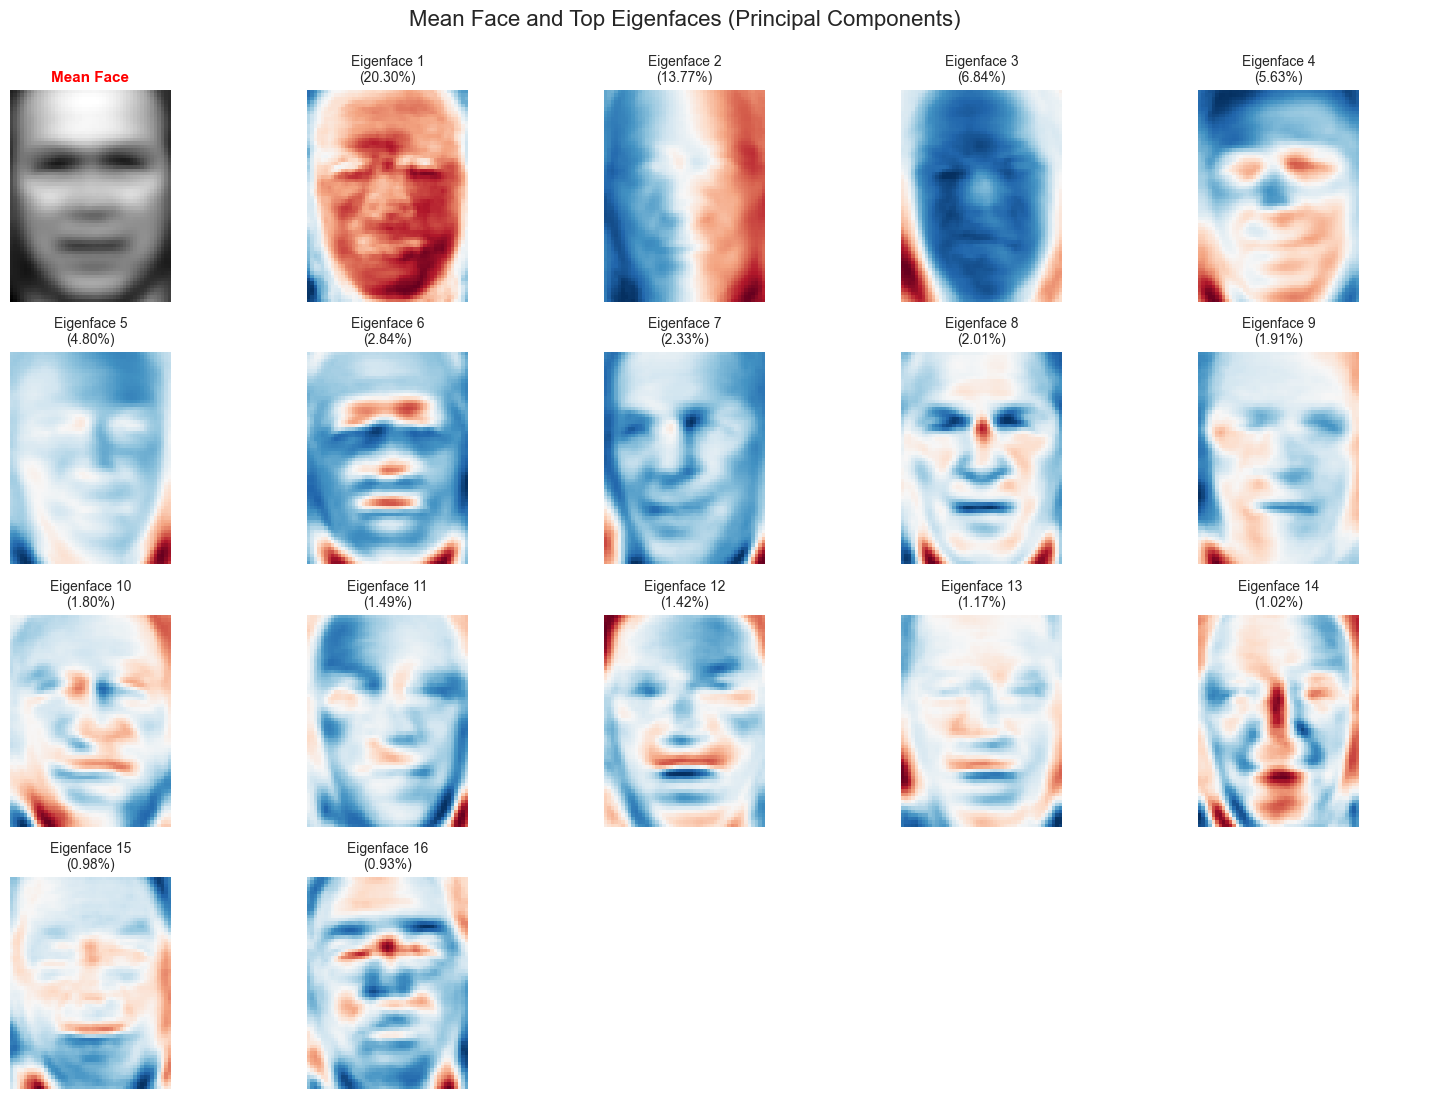


🎭 Interpreting the Eigenfaces:

Mean Face: The average of all faces in the dataset

Eigenface 1 (largest eigenvalue): Usually captures overall lighting/brightness variations

Eigenface 2-3: Often capture major facial structure variations

Later eigenfaces: Capture more subtle, specific features

Colors: Red = positive contribution, Blue = negative contribution, White = neutral


In [13]:
# Visualize the mean face and top eigenfaces
n_eigenfaces = 16
fig, axes = plt.subplots(4, 5, figsize=(15, 11))
fig.suptitle('Mean Face and Top Eigenfaces (Principal Components)', fontsize=16, y=0.995)

# Plot mean face first
axes[0, 0].imshow(scaler.mean_.reshape(h, w), cmap='gray')
axes[0, 0].set_title('Mean Face', fontsize=11, fontweight='bold', color='red')
axes[0, 0].axis('off')

# Plot top eigenfaces
for i in range(1, n_eigenfaces + 1):
    row = i // 5
    col = i % 5
    
    # Get eigenface (principal component reshaped to image)
    eigenface = pca_faces.components_[i-1].reshape(h, w)
    
    # Plot
    axes[row, col].imshow(eigenface, cmap='RdBu_r')  # Blue-white-red to show +/- contributions
    var_pct = pca_faces.explained_variance_ratio_[i-1] * 100
    axes[row, col].set_title(f'Eigenface {i}\n({var_pct:.2f}%)', fontsize=10)
    axes[row, col].axis('off')

# Hide remaining subplots
for i in range(n_eigenfaces + 1, 20):
    row = i // 5
    col = i % 5
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("\n🎭 Interpreting the Eigenfaces:")
print("\nMean Face: The average of all faces in the dataset")
print("\nEigenface 1 (largest eigenvalue): Usually captures overall lighting/brightness variations")
print("\nEigenface 2-3: Often capture major facial structure variations")
print("\nLater eigenfaces: Capture more subtle, specific features")
print("\nColors: Red = positive contribution, Blue = negative contribution, White = neutral")

## 3.4 Reconstructing Faces from Eigenfaces

Let's see how well we can reconstruct a face using different numbers of eigenfaces.

This demonstrates **dimensionality reduction**: we can represent a 4,096-dimensional face with just 10-50 numbers!

## 🎯 Exc 3.5 Interactive Eigenface Reconstruction

Let's create an interactive visualization showing how adding more eigenfaces progressively builds up a face.

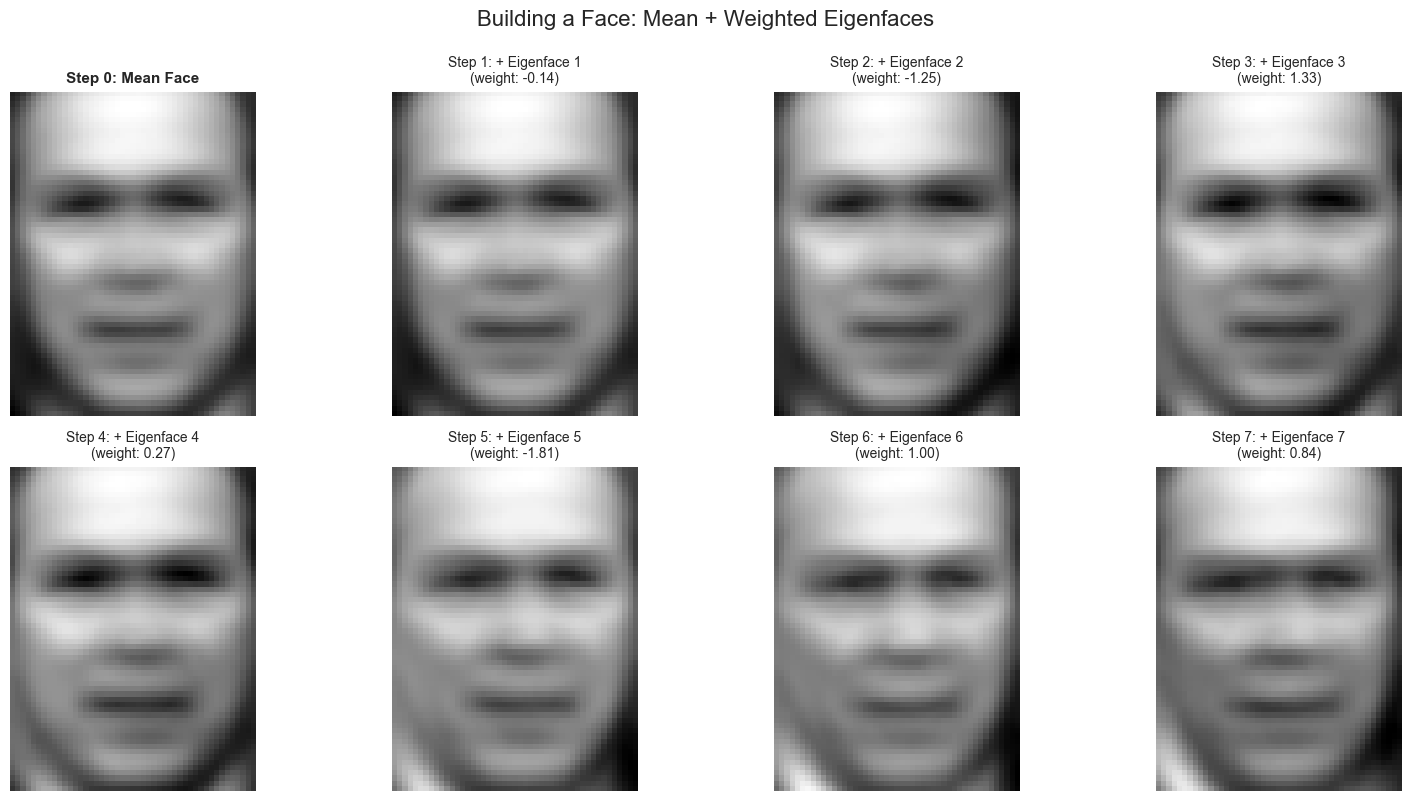


🔨 How Face Reconstruction Works:

1. Start with the mean face (average of all faces)
2. Add the first eigenface, scaled by its weight for this person
3. Add the second eigenface, scaled by its weight
4. Continue adding weighted eigenfaces...

Each eigenface adds more detail and makes the face more specific!


In [ ]:
# Create step-by-step reconstruction showing contribution of each eigenface
face_idx = 42
n_steps = 8

# Get the PC scores (weights) for this face
face_pca_scores = faces_pca[face_idx]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle('Building a Face: Mean + Weighted Eigenfaces', fontsize=16, y=0.995)

# Start with mean face
reconstruction = scaler.mean_.copy()

for i in range(n_steps):
    if i == 0:
        # Show mean face
        axes[i].imshow(reconstruction.reshape(h, w), cmap='gray')
        axes[i].set_title('Step 0: Mean Face', fontsize=11, fontweight='bold')
    else:
        # Add contribution from eigenface i
        ## TODO: Add weighted eigenface to reconstruction
        weight = None
        eigenface = None
        reconstruction = None
        
        axes[i].imshow(reconstruction.reshape(h, w), cmap='gray')
        axes[i].set_title(f'Step {i}: + Eigenface {i}\n(weight: {weight:.2f})', fontsize=10)
    
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\n🔨 How Face Reconstruction Works:")
print("\n1. Start with the mean face (average of all faces)")
print("2. Add the first eigenface, scaled by its weight for this person")
print("3. Add the second eigenface, scaled by its weight")
print("4. Continue adding weighted eigenfaces...")
print("\nEach eigenface adds more detail and makes the face more specific!")

In [ ]:
# ## solution
# weight = face_pca_scores[i-1]
# eigenface = pca_faces.components_[i-1]
# reconstruction = reconstruction + weight * eigenface

## 3.6 Visualizing Face Space

We can visualize how different people cluster in "eigenface space" (the PC space).

In [16]:
# Create interactive 3D scatter plot of faces in PC space
# Color by person
targets = lfw_people.target

fig = go.Figure(data=[go.Scatter3d(
    x=faces_pca[:, 0],
    y=faces_pca[:, 1],
    z=faces_pca[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=targets,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Person ID")
    ),
    text=[target_names[t] for t in targets],
    hovertemplate='%{text}<br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>'
)])

fig.update_layout(
    title='Face Space: First 3 Principal Components',
    scene=dict(
        xaxis_title=f'PC1 ({pca_faces.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({pca_faces.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({pca_faces.explained_variance_ratio_[2]*100:.1f}%)'
    ),
    width=800,
    height=700
)

fig.show()

print("\n🎯 What this shows:")
print("- Each point is a face image in 3D PC space")
print("- Faces of the same person cluster together (same color)")
print("- Similar-looking people are close in this space")
print("- We reduced 4,096 dimensions to 3 while preserving face identity!")
print("\n💡 This is the basis for face recognition systems!")


🎯 What this shows:
- Each point is a face image in 3D PC space
- Faces of the same person cluster together (same color)
- Similar-looking people are close in this space
- We reduced 4,096 dimensions to 3 while preserving face identity!

💡 This is the basis for face recognition systems!


---

# Part 4: Hands-on Exercises

## Exercise 1: Understanding Eigenvalues

**Task**: Create data with different eigenvalue structures and visualize them.

In [ ]:
# =============================================================================
# EXERCISE 1: Create and Analyze Different Covariance Structures
# =============================================================================
# TODO: Create three datasets with different eigenvalue patterns
# HINT: Use np.random.multivariate_normal(mean, cov, n_samples)
# HINT: Control eigenvalues by choosing covariance matrices carefully

np.random.seed(42)
n = 300

# Dataset 1: One dominant eigenvalue (highly elongated)
# TODO: Create covariance matrix with eigenvalues ≈ [10, 0.5]
cov1 = np.array([[10, 0],
                 [0, 0.5]])
data1 = np.random.multivariate_normal([0, 0], cov1, n)

# Dataset 2: Balanced eigenvalues (circular)
# TODO: Create covariance matrix with eigenvalues ≈ [3, 3]
cov2 = # YOUR CODE HERE
data2 = # YOUR CODE HERE

# Dataset 3: Correlated features (tilted ellipse)
# TODO: Create covariance matrix with off-diagonal elements
cov3 = # YOUR CODE HERE
data3 = # YOUR CODE HERE

# Apply PCA to each dataset
pca1 = PCA().fit(data1)
pca2 = PCA().fit(data2)
pca3 = PCA().fit(data3)

# TODO: Print eigenvalues for each dataset
# YOUR CODE HERE

# TODO: Create visualization comparing the three datasets
# HINT: Use subplots to show all three side-by-side
# YOUR CODE HERE

In [ ]:
# =============================================================================
# SOLUTION - Exercise 1
# =============================================================================
# Uncomment to reveal:

# np.random.seed(42)
# n = 300

# # Dataset 1: One dominant eigenvalue
# cov1 = np.array([[10, 0], [0, 0.5]])
# data1 = np.random.multivariate_normal([0, 0], cov1, n)

# # Dataset 2: Balanced eigenvalues
# cov2 = np.array([[3, 0], [0, 3]])
# data2 = np.random.multivariate_normal([0, 0], cov2, n)

# # Dataset 3: Correlated features
# cov3 = np.array([[4, 2.5], [2.5, 3]])
# data3 = np.random.multivariate_normal([0, 0], cov3, n)

# # Apply PCA
# pca1 = PCA().fit(data1)
# pca2 = PCA().fit(data2)
# pca3 = PCA().fit(data3)

# print("Eigenvalues:")
# print(f"Dataset 1: {pca1.explained_variance_}")
# print(f"Dataset 2: {pca2.explained_variance_}")
# print(f"Dataset 3: {pca3.explained_variance_}")

# # Visualization
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# datasets = [data1, data2, data3]
# pcas = [pca1, pca2, pca3]
# titles = ['Dominant PC1', 'Balanced PCs', 'Correlated Features']

# for ax, data, pca, title in zip(axes, datasets, pcas, titles):
#     ax.scatter(data[:, 0], data[:, 1], alpha=0.5, s=20)
#     
#     # Plot PCs
#     for i in range(2):
#         vec = pca.components_[i] * pca.explained_variance_[i] * 0.5
#         ax.arrow(0, 0, vec[0], vec[1], 
#                 head_width=0.3, head_length=0.3, fc=f'C{i+1}', ec=f'C{i+1}', 
#                 linewidth=2, label=f'PC{i+1} (λ={pca.explained_variance_[i]:.2f})')
#     
#     ax.set_xlim(-8, 8)
#     ax.set_ylim(-8, 8)
#     ax.set_aspect('equal')
#     ax.set_title(title)
#     ax.legend()
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

## Exercise 2: Dimensionality Reduction Trade-off

**Task**: Explore how many PCs you need to keep to reconstruct the data accurately.

In [ ]:
# =============================================================================
# EXERCISE 2: Reconstruction Error vs Number of Components
# =============================================================================
# TODO: Compute reconstruction error for different numbers of PCs
# HINT: Reconstruct data using X_reconstructed = X_pca @ components.T + mean
# HINT: Error = mean squared difference between original and reconstructed

# Use the behavioral data from earlier
X_original = X_scaled  # Already scaled

# TODO: For each number of components (1 to 16), compute reconstruction error
n_components_range = range(1, 17)
reconstruction_errors = []

for n_comp in n_components_range:
    # TODO: Fit PCA with n_comp components
    pca_temp = # YOUR CODE HERE
    
    # TODO: Transform and inverse transform to reconstruct
    X_reconstructed = # YOUR CODE HERE
    
    # TODO: Calculate mean squared error
    error = # YOUR CODE HERE
    reconstruction_errors.append(error)

# TODO: Plot reconstruction error vs number of components
# YOUR CODE HERE

# TODO: Find elbow point (where error drops below some threshold)
# YOUR CODE HERE

In [ ]:
# =============================================================================
# SOLUTION - Exercise 2
# =============================================================================
# Uncomment to reveal:

# X_original = X_scaled
# n_components_range = range(1, 17)
# reconstruction_errors = []

# for n_comp in n_components_range:
#     pca_temp = PCA(n_components=n_comp)
#     X_transformed = pca_temp.fit_transform(X_original)
#     X_reconstructed = pca_temp.inverse_transform(X_transformed)
#     
#     error = np.mean((X_original - X_reconstructed) ** 2)
#     reconstruction_errors.append(error)

# # Plot
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(n_components_range, reconstruction_errors, 'bo-', linewidth=2, markersize=8)
# ax.set_xlabel('Number of Components', fontsize=12)
# ax.set_ylabel('Reconstruction Error (MSE)', fontsize=12)
# ax.set_title('Reconstruction Error vs Number of Components', fontsize=14)
# ax.grid(True, alpha=0.3)
# plt.show()

# # Find elbow
# threshold_error = 0.1  # 10% of original variance
# elbow_idx = np.argmax(np.array(reconstruction_errors) < threshold_error)
# print(f"\nWith {n_components_range[elbow_idx]} components, error < {threshold_error}")
# print(f"This represents {n_components_range[elbow_idx]/16*100:.0f}% of original dimensions")

---

# Part 5: Summary and Key Takeaways

## What We Learned

### 1. **Eigenvectors and Eigenvalues**
- **Eigenvector**: Special direction that doesn't rotate under transformation
- **Eigenvalue**: How much the eigenvector gets stretched/compressed
- **Large eigenvalue**: Direction of high variance (important)
- **Small eigenvalue**: Direction of low variance (noise)

### 2. **PCA Mechanics**
- Computes eigenvectors of the **covariance matrix**
- Sorts by eigenvalue (largest first)
- Projects data onto top eigenvectors (principal components)
- Reduces dimensionality while preserving variance

### 3. **Interpretation**
- **Scree plot**: Visualize eigenvalue spectrum, look for "elbow"
- **Cumulative variance**: How much information is retained
- **Component loadings**: Which features contribute to each PC
- **PC scores**: New coordinates in reduced space

### 4. **Applications in Behavioral Analysis**
- **Dimensionality reduction**: 16 body parts → 3-5 meaningful PCs
- **Visualization**: High-D data → 2D/3D plots
- **Feature extraction**: PCs as input to clustering/classification
- **Noise reduction**: Keep signal, discard noise

---

## When to Use PCA

✅ **Good for:**
- High-dimensional continuous data (many features)
- When features are correlated
- Visualizing data structure
- Preprocessing for machine learning
- Identifying main axes of variation

❌ **Not ideal for:**
- Categorical/binary data
- When features are already independent
- When you need interpretable features (PCs are linear combinations)
- Highly nonlinear data (consider t-SNE, UMAP)

---

## Common Pitfalls

1. **Forgetting to standardize**: Features with different scales will dominate
2. **Over-interpreting small eigenvalues**: They're often just noise
3. **Assuming linearity**: PCA finds linear combinations; won't capture complex nonlinear patterns
4. **Ignoring biological meaning**: Just because a PC explains variance doesn't mean it's biologically relevant

---

## Extensions and Next Steps

- **Kernel PCA**: Handle nonlinear relationships
- **Sparse PCA**: Get interpretable components (fewer features per PC)
- **Probabilistic PCA**: Account for noise, handle missing data
- **Dynamic PCA**: For time-series data
- **UMAP/t-SNE**: Nonlinear dimensionality reduction for visualization

---

## Reflection Questions

1. Why do we use the covariance matrix instead of just the data matrix?
2. What would happen if you didn't center the data before PCA?
3. How would you decide between PCA and other dimensionality reduction methods?
4. Can you think of a behavioral analysis problem where PCA might not work well?

---

## Additional Resources

- [StatQuest PCA Video](https://www.youtube.com/watch?v=FgakZw6K1QQ) - Excellent intuitive explanation
- [Scikit-learn PCA User Guide](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- *Pattern Recognition and Machine Learning* by Bishop (Chapter 12)
- [PCA Visualization Tool](https://setosa.io/ev/principal-component-analysis/)

---

**Congratulations!** You now understand the mathematical foundations of PCA and we will to apply it to behavioral data on Day4. 🎉